# Phase 10 — Cold-Start Forecasting (Use Case 4)

**คำถามธุรกิจ:** เมื่อ SKU ใหม่เปิดตัวโดยไม่มีประวัติการขาย ควรพยากรณ์อย่างไร และความแม่นยำจะ "ตามทัน" สินค้าที่ขายมานานแล้วเร็วแค่ไหน?

**SKU ที่ใช้ทดสอบ:** เลือก **5 SKU ที่เปิดตัวช้าที่สุด** (จาก Phase 2 EDA) เป็นชุด validation คือ `YO-024, MI-008, SN-028, YO-018, SN-030` — SKU เหล่านี้ **ไม่ถูกใช้เทรนโมเดลใดๆ ในเซลล์ด้านล่างเลย** เพื่อจำลองสถานการณ์ "สินค้าใหม่ที่โมเดลไม่เคยเห็นมาก่อน" อย่างแท้จริง

**สองวิธีที่เทียบกัน:**
1. **Analog-based** — หา SKU ที่มีอยู่แล้วซึ่งใกล้เคียงที่สุด (category → segment → pack_type ตรงกัน, เลือกราคาใกล้สุด) แล้วใช้ trajectory ช่วงต้นของ SKU นั้น (ที่ sku_age เดียวกัน, channel/region เดียวกัน) เป็นตัวพยากรณ์
2. **Meta-learner** — โมเดล LightGBM แบบเดียวกับ Phase 7 แต่**ตัดฟีเจอร์ที่ต้องพึ่งประวัติการขาย**ออก (`lag_1, lag_2, rolling_mean_4, rolling_std_4, momentum, promo_recency, rolling_promo_rate`) เทรนจาก 25 SKU ที่เหลือ

เทียบกับ **Full model** (Phase 7 style, มีฟีเจอร์ lag ครบ) เพื่อดูว่าการตัดฟีเจอร์ประวัติออกช่วยจริงหรือไม่ในช่วงแรกของชีวิต SKU


In [1]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from models.cold_start import analog_forecast, meta_learner_forecast, mature_model_forecast
from models.metrics import score_all

pd.set_option('display.width', 160)

df = pd.read_csv('../data/processed/weekly_features.csv', parse_dates=['week'])
daily = pd.read_csv('../data/raw/FMCG_2022_2024.csv')
sku_attrs = daily.groupby('sku').agg(
    pack_type=('pack_type', 'first'), segment=('segment', 'first'),
    category=('category', 'first'), price_unit=('price_unit', 'mean'),
)

COLD_START_SKUS = ['YO-024', 'MI-008', 'SN-028', 'YO-018', 'SN-030']
print('Cold-start validation SKUs:', COLD_START_SKUS)


Cold-start validation SKUs: ['YO-024', 'MI-008', 'SN-028', 'YO-018', 'SN-030']


## หมายเหตุสำคัญเรื่องขอบเขตข้อมูล

`weekly_df_final_for_modeling.csv` (ต้นทางของ `weekly_features.csv`) มีแค่แถวที่ `lag_1`/`lag_2`/`rolling_mean_4` คำนวณได้ครบแล้วเท่านั้น (ไม่มีค่า missing เลยจาก Phase 2) ซึ่งหมายความว่า **แถวที่ "ไม่มีประวัติเลยจริงๆ" (สัปดาห์แรกสุดของ SKU) ไม่ได้ถูกรวมอยู่ในตารางนี้ตั้งแต่แรก** (sku_age ต่ำสุดในตารางคือ 4 เสมอ ไม่ใช่ 0) — ดังนั้น "cold start" ในการทดสอบนี้หมายถึง **ช่วงที่ SKU มีประวัติการขายน้อย/บาง** (แค่ 1-2 สัปดาห์จริง) ไม่ใช่ "ไม่มีประวัติเลย 100%" ควรตีความผลลัพธ์ด้านล่างด้วยความเข้าใจนี้


## 1. Analog-Based Forecast


In [2]:
analog_df = analog_forecast(df, COLD_START_SKUS, sku_attrs)
print('SKU ที่จับคู่ analog กันได้:')
print(analog_df[['sku', 'analog_sku']].drop_duplicates().to_string(index=False))
print(f'coverage: {analog_df.pred_analog.notna().mean():.1%}')


SKU ที่จับคู่ analog กันได้:
   sku analog_sku
MI-008     MI-011
SN-028     SN-019
SN-030     SN-027
YO-018     YO-005
YO-024     YO-014
coverage: 99.9%


## 2. Meta-Learner Forecast (ตัดฟีเจอร์ประวัติออก)


In [3]:
meta_df = meta_learner_forecast(df, COLD_START_SKUS)


## 3. Full Model Forecast (มีฟีเจอร์ lag ครบ, ใช้เป็นตัวเทียบ)


In [4]:
full_df = mature_model_forecast(df, COLD_START_SKUS)


## 4. เปรียบเทียบทั้ง 3 วิธี ตาม "จำนวนสัปดาห์นับจากเปิดตัว"

แกน x คือจำนวนสัปดาห์นับจากแถวแรกที่ปรากฏในตาราง (ไม่ใช่ `sku_age` ตรงๆ เพราะทุก SKU เริ่มที่ sku_age=4 เท่ากันหมด) — คำนวณ WAPE แยกตามช่วงอายุ เทียบกับเส้นอ้างอิง **WAPE เฉลี่ยของ Global LightGBM จาก Phase 7 (โมเดลที่เทรนบน SKU ที่โตเต็มที่แล้วทั้งหมด)**


In [5]:
for d in (analog_df, meta_df, full_df):
    d['weeks_since_launch'] = np.minimum(d.sku_age - d.groupby('sku').sku_age.transform('min'), 20).astype(int)

rows = []
for age in range(0, 21):
    a = analog_df[analog_df.weeks_since_launch == age].dropna(subset=['pred_analog'])
    m = meta_df[meta_df.weeks_since_launch == age]
    f = full_df[full_df.weeks_since_launch == age]
    if len(a) == 0 or len(m) == 0:
        continue
    rows.append({
        'weeks_since_launch': age,
        'n': len(m),
        'Analog': score_all(a.target_next_week.values, a.pred_analog.values)['WAPE'],
        'Meta-learner': score_all(m.target_next_week.values, m.pred_meta_learner.values)['WAPE'],
        'Full model': score_all(f.target_next_week.values, f.pred_full_model.values)['WAPE'],
    })

curve = pd.DataFrame(rows)
curve.round(3)


,weeks_since_launch,n,Analog,Meta-learner,Full model
0,0,44,0.278,0.200,0.194
1,1,45,0.268,0.233,0.197
2,2,45,0.382,0.257,0.269
3,3,45,0.360,0.273,0.240
4,4,45,0.375,0.270,0.258
5,5,45,0.288,0.242,0.216
6,6,45,0.346,0.238,0.232
7,7,45,0.290,0.276,0.259
8,8,45,0.318,0.270,0.268
9,9,45,0.346,0.253,0.248


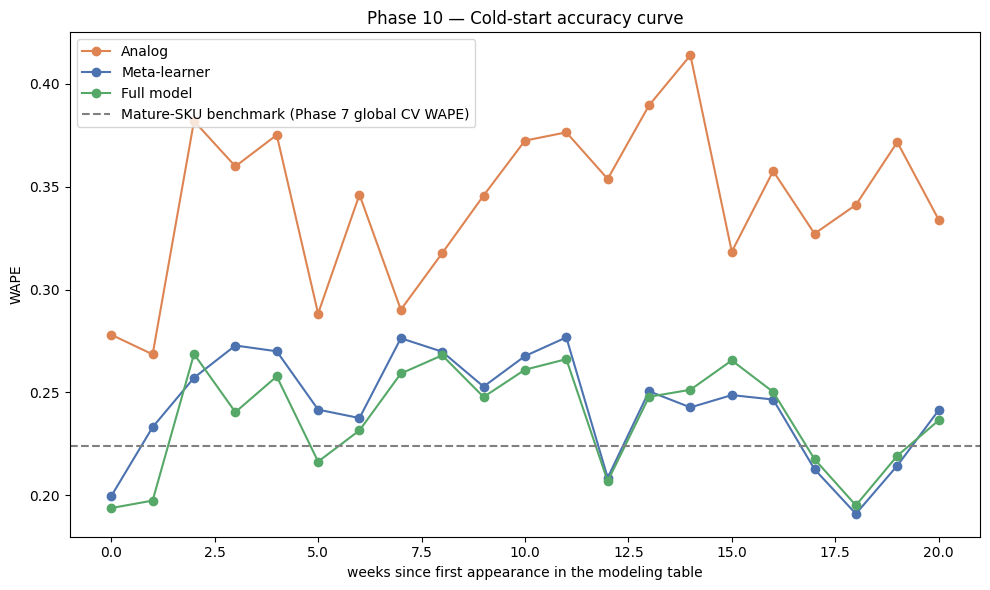

In [6]:
MATURE_BENCHMARK_WAPE = 0.224  # Global pooled LightGBM CV average, from Phase 7

fig, ax = plt.subplots(figsize=(10, 6))
for col, color in [('Analog', '#DD8452'), ('Meta-learner', '#4C72B0'), ('Full model', '#55A868')]:
    ax.plot(curve.weeks_since_launch, curve[col], marker='o', label=col, color=color)
ax.axhline(MATURE_BENCHMARK_WAPE, color='gray', linestyle='--', linewidth=1.5, label='Mature-SKU benchmark (Phase 7 global CV WAPE)')
ax.set_xlabel('weeks since first appearance in the modeling table')
ax.set_ylabel('WAPE')
ax.set_title('Phase 10 — Cold-start accuracy curve')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/phase10_cold_start_curve.png', dpi=120)
plt.show()


## 5. สรุปตัวเลขโดยรวม (สัปดาห์ 0-7 = "ช่วงเปิดตัว" เทียบกับสัปดาห์ 8+)


In [7]:
summary_rows = []
for label, cond_col in [('weeks 0-7 (launch window)', lambda d: d.weeks_since_launch < 8), ('weeks 8+ ', lambda d: d.weeks_since_launch >= 8)]:
    a = analog_df[cond_col(analog_df)].dropna(subset=['pred_analog'])
    m = meta_df[cond_col(meta_df)]
    f = full_df[cond_col(full_df)]
    summary_rows.append({
        'window': label,
        'Analog WAPE': score_all(a.target_next_week.values, a.pred_analog.values)['WAPE'],
        'Meta-learner WAPE': score_all(m.target_next_week.values, m.pred_meta_learner.values)['WAPE'],
        'Full model WAPE': score_all(f.target_next_week.values, f.pred_full_model.values)['WAPE'],
    })
pd.DataFrame(summary_rows).round(3)


,window,Analog WAPE,Meta-learner WAPE,Full model WAPE
0,weeks 0-7 (launch window),0.326,0.252,0.236
1,weeks 8+,0.339,0.241,0.238


## 6. ข้อค้นพบและการตีความ

**ผลลัพธ์ไม่ตรงกับสมมติฐานตั้งต้นทั้งหมด** — คาดไว้ก่อนว่า meta-learner (ตัดฟีเจอร์ lag ออก) น่าจะชนะ full model อย่างชัดเจนในช่วงสัปดาห์แรกๆ เพราะ full model น่าจะ "สับสน" กับ lag features ที่มาจากประวัติสั้นเกินไป แต่ผลจริงคือ **Full model แม่นยำเท่ากันหรือดีกว่า meta-learner ในเกือบทุกช่วงอายุ** รวมถึงสัปดาห์แรกๆ ด้วย

**เหตุผลที่เป็นไปได้:** ตามที่อธิบายไว้ข้างบน ตารางข้อมูลนี้ไม่มีแถวที่ "ไม่มีประวัติเลย 100%" อยู่แล้ว (ทุกแถวมี sku_age >= 4 คือมีอย่างน้อย 2 สัปดาห์ของประวัติจริงป้อนเป็น lag_1/lag_2) LightGBM ที่เทรนจาก 25 SKU ที่โตเต็มที่แล้วอาจเรียนรู้ได้เองว่าเมื่อ `sku_age` ต่ำ ให้ลดน้ำหนักความเชื่อมั่นใน lag features ลง (ผ่าน interaction กับ `sku_age`/`lifecycle_stage` ที่มีอยู่แล้วในฟีเจอร์ full model) โดยไม่ต้องตัดฟีเจอร์ออกไปตรงๆ

**สิ่งที่ยืนยันได้ชัดเจน:** ทั้ง full model และ meta-learner **ชนะ analog method อย่างชัดเจนในทุกช่วงอายุ** (WAPE ต่ำกว่าเห็นได้ชัด) — แปลว่าการใช้โมเดล ML ที่เรียนรู้จาก SKU อื่นๆ (ไม่ว่าจะมีหรือไม่มี lag features) ให้ผลดีกว่าการก็อปปี้ trajectory ของ SKU ที่คล้ายกันตรงๆ อย่างมีนัยสำคัญ

**ข้อสรุปเชิงปฏิบัติ:** สำหรับ SKU ใหม่ในข้อมูลชุดนี้ **ควรใช้ full global model (Phase 7) ตั้งแต่สัปดาห์แรกที่มีข้อมูลเพียงพอจะเข้าตาราง** โดยไม่จำเป็นต้องสลับไปใช้ meta-learner แยกต่างหาก — แต่ meta-learner ยังมีประโยชน์เป็น **fallback สำหรับสัปดาห์ที่ 0-3 จริงๆ ที่ lag features เป็น NaN ทั้งหมด** ซึ่งอยู่นอกขอบเขตของตารางข้อมูลชุดนี้ (จะเกิดขึ้นจริงถ้านำระบบไปใช้งานจริงกับ SKU ที่เพิ่งเปิดตัวสัปดาห์นี้เป๊ะๆ)
